- Momentum: RSI, MACD Histogram
- Volatility: ATR, Bollinger %B
- Volume: MFI, Volume Ratio

In [28]:
import yfinance as yf
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, "/Users/giovanafalcao/Desktop/Projects/trading-analytics")
from utils import yfinance_fix
import matplotlib.pyplot as plt


TICKER = "AAPL"
INTERVAL = "1h"
PERIOD = "730d" if INTERVAL == "1h" else "max"
LOOKBACK = 10000

def fetch_price_data(ticker=TICKER, interval=INTERVAL, period=PERIOD, lookback=LOOKBACK):
    df = yf.download(ticker, session=yfinance_fix.chrome_session, interval=interval, period=period)
    df.columns = df.columns.get_level_values(0)
    return df.iloc[-lookback:, :]

df = fetch_price_data()
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2023-05-22 13:30:00+00:00,174.192001,174.710007,173.449997,173.979996,12346138
2023-05-22 14:30:00+00:00,174.488800,174.600006,173.600006,174.199997,5485289
2023-05-22 15:30:00+00:00,174.160004,174.550003,173.929993,174.479996,4041203
2023-05-22 16:30:00+00:00,174.220001,174.389999,173.869995,174.145004,4605162
2023-05-22 17:30:00+00:00,174.320007,174.520004,174.089996,174.229996,3217043
...,...,...,...,...,...
2026-04-20 15:30:00+00:00,272.570007,272.910004,272.079987,272.829987,2499488
2026-04-20 16:30:00+00:00,272.190002,273.135010,271.839996,272.589996,2403500
2026-04-20 17:30:00+00:00,273.450012,273.640015,271.980011,272.170013,2711593


Measuring Momentum:

1. RSI (Relative Strength Index, 14d): measures speed and magnitude of recent price changes on a 0-100 scale. RSI > 70 = overbought (might drop), RSI < 30 = oversold (might bounce). Formula: RSI = 100 - 100/(1 + avg_gain/avg_loss) over 14 days. Unlike raw momentum (pct_change), RSI is bounded and already stationary.

2. MACD Histogram: difference between MACD line (EMA12 - EMA26) and its signal line (EMA9 of MACD). Positive histogram = bullish momentum increasing, negative = bearish. Crossing zero = momentum shift.

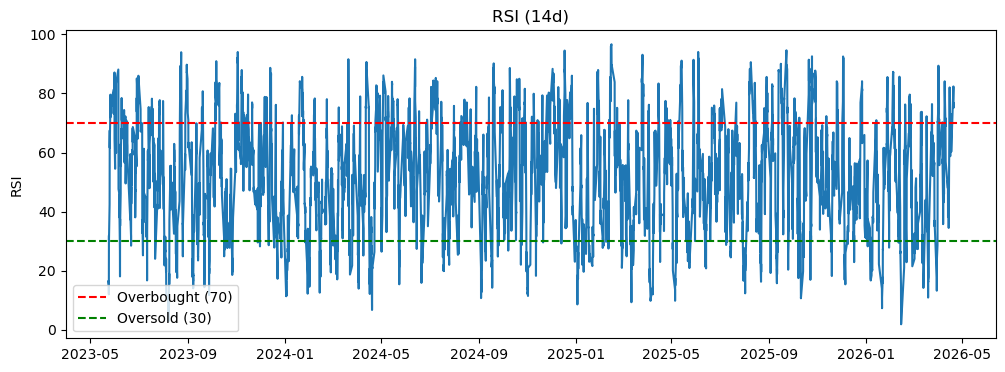

In [29]:
# RSI = 100 - 100 / (1 + avg_gain / avg_loss) over 14 days
RSI_LENGTH = 14

def calculate_RSI(df, length=RSI_LENGTH):
    price_change = df["Close"].diff()
    df["gain"] = price_change.where(price_change > 0, 0)
    df["loss"] = -price_change.where(price_change < 0, 0)
    df["avg_gain"] = df["gain"].rolling(window=length).mean()
    df["avg_loss"] = df["loss"].rolling(window=length).mean()
    rs = df["avg_gain"] / df["avg_loss"]
    df["RSI"] = 100 - (100 / (1 + rs))
    df = df.drop(columns=["gain", "loss", "avg_gain", "avg_loss"])

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["RSI"])
    plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
    plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
    plt.title("RSI (14d)")
    plt.ylabel("RSI")
    plt.legend()
    plt.show()
    return df

df = calculate_RSI(df)

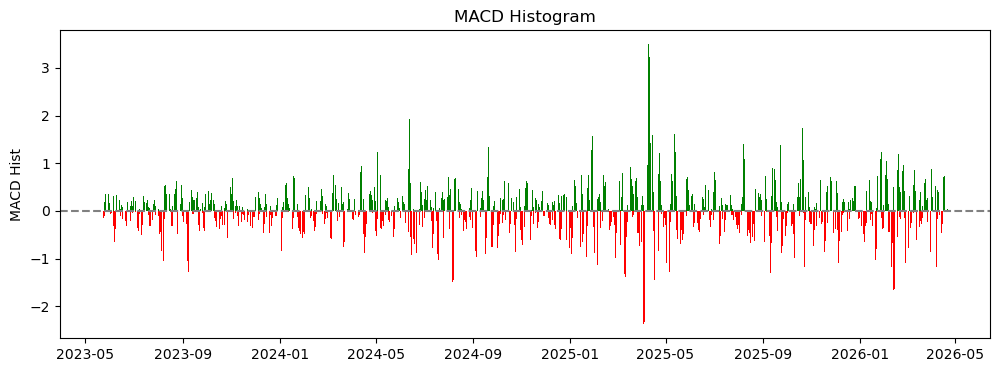

In [30]:
# MACD Histogram = MACD line (EMA12 - EMA26) - Signal line (EMA9 of MACD)
def calculate_MACD(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast).mean()
    ema_slow = df["Close"].ewm(span=slow).mean()
    df["MACD"] = ema_fast - ema_slow
    df["MACD_Signal"] = df["MACD"].ewm(span=signal).mean()
    df["MACD_HIST"] = df["MACD"] - df["MACD_Signal"]

    plt.figure(figsize=(12, 4))
    plt.bar(df.index, df["MACD_HIST"], color=np.where(df["MACD_HIST"] >= 0, "green", "red"), width=1)
    plt.axhline(0, color="gray", linestyle="--")
    plt.title("MACD Histogram")
    plt.ylabel("MACD Hist")
    plt.show()
    return df

df = calculate_MACD(df)

Measuring Volatility:

3. ATR (Average True Range, 14d): average daily price range including gaps. True Range = max(High-Low, |High-PrevClose|, |Low-PrevClose|). Higher ATR = more volatile. Unlike HV_20 (which uses log returns), ATR uses absolute price ranges — useful for position sizing and stop-loss placement.

4. Bollinger %B (20d, 2 std): where is the price relative to its Bollinger Bands? %B = (Price - Lower) / (Upper - Lower). %B > 1 = above upper band, %B < 0 = below lower band, %B = 0.5 = at the middle. This is essentially a z-score of price.

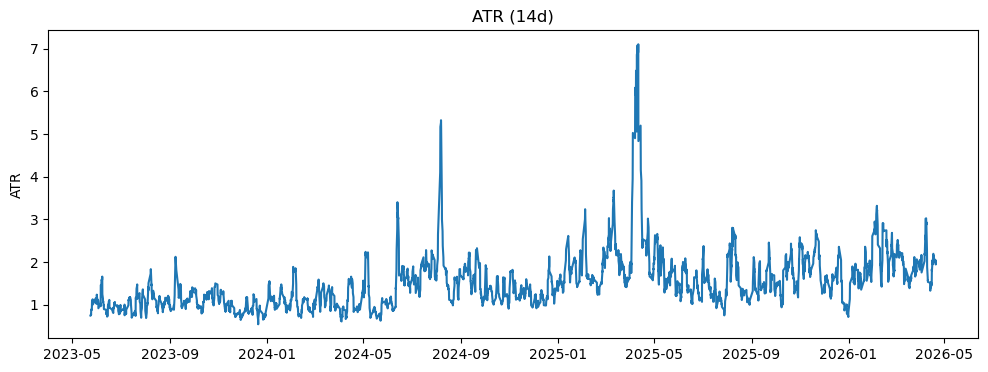

In [31]:
# ATR = rolling mean of True Range over 14 days
# True Range = max(High-Low, |High-PrevClose|, |Low-PrevClose|)
def calculate_ATR(df, period=14):
    high_low = df["High"] - df["Low"]
    high_close = (df["High"] - df["Close"].shift(1)).abs()
    low_close = (df["Low"] - df["Close"].shift(1)).abs()
    df["TR"] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df["ATR"] = df["TR"].rolling(period).mean()
    df = df.drop(columns=["TR"])

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["ATR"])
    plt.title("ATR (14d)")
    plt.ylabel("ATR")
    plt.show()
    return df

df = calculate_ATR(df)

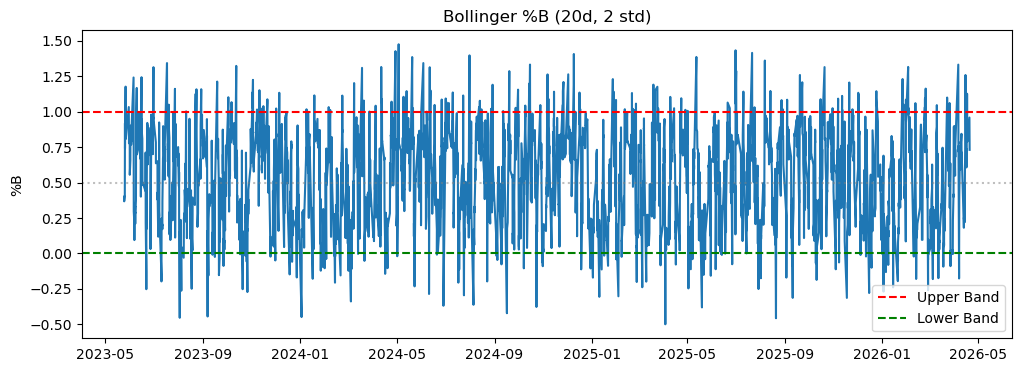

In [32]:
# Bollinger %B = (Price - Lower) / (Upper - Lower)
# Upper = SMA(20) + 2*std, Lower = SMA(20) - 2*std
def calculate_BB(df, period=20, std=2):
    sma = df["Close"].rolling(period).mean()
    rolling_std = df["Close"].rolling(period).std()
    upper = sma + std * rolling_std
    lower = sma - std * rolling_std
    df["BB_Percent"] = (df["Close"] - lower) / (upper - lower)

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["BB_Percent"])
    plt.axhline(1, color="red", linestyle="--", label="Upper Band")
    plt.axhline(0, color="green", linestyle="--", label="Lower Band")
    plt.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
    plt.title("Bollinger %B (20d, 2 std)")
    plt.ylabel("%B")
    plt.legend()
    plt.show()
    return df

df = calculate_BB(df)

Measuring Volume:

5. MFI (Money Flow Index, 14d): like RSI but weighted by volume. Measures buying vs selling pressure. MFI > 80 = overbought with high volume (strong conviction), MFI < 20 = oversold. Formula: RSI applied to money flow (typical_price x volume) instead of just price.

6. Volume Ratio: today's volume / 20-day average volume. Ratio > 1 = above-average activity, < 1 = quiet day. High volume confirms price moves — a big price move on low volume is less trustworthy.

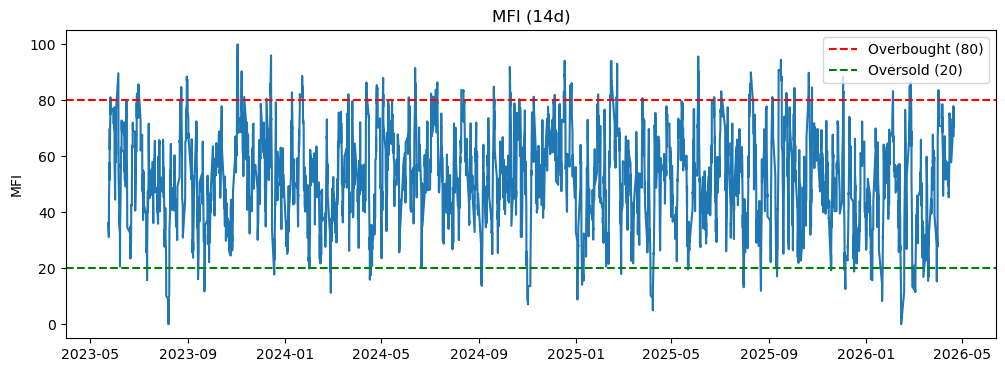

In [33]:
# MFI = RSI applied to money flow (typical_price * volume)
def calculate_MFI(df, period=14):
    typical = (df["High"] + df["Low"] + df["Close"]) / 3
    money_flow = typical * df["Volume"]
    delta = typical.diff()
    pos_flow = money_flow.where(delta > 0, 0).rolling(period).sum()
    neg_flow = money_flow.where(delta < 0, 0).rolling(period).sum()
    df["MFI"] = 100 - (100 / (1 + pos_flow / neg_flow))

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["MFI"])
    plt.axhline(80, color="red", linestyle="--", label="Overbought (80)")
    plt.axhline(20, color="green", linestyle="--", label="Oversold (20)")
    plt.title("MFI (14d)")
    plt.ylabel("MFI")
    plt.legend()
    plt.show()
    return df

df = calculate_MFI(df)

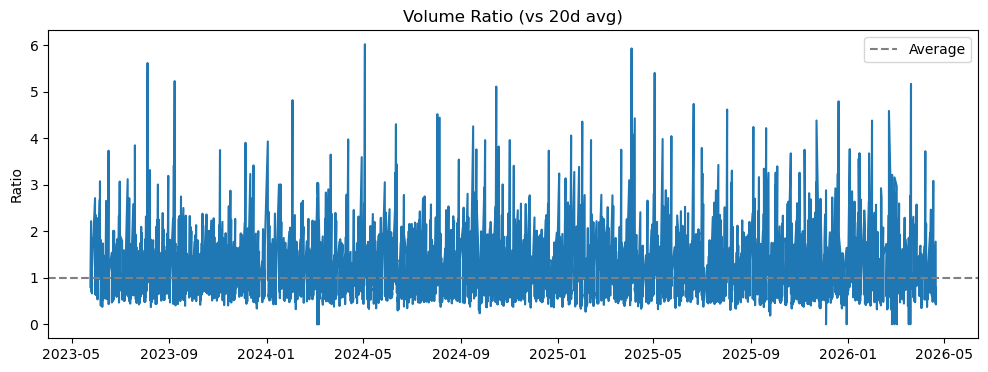

In [34]:
# Volume Ratio = today's volume / 20-day average volume
def calculate_Volume_Ratio(df, period=20):
    df["Volume_Ratio"] = df["Volume"] / df["Volume"].rolling(period).mean()

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["Volume_Ratio"])
    plt.axhline(1, color="gray", linestyle="--", label="Average")
    plt.title("Volume Ratio (vs 20d avg)")
    plt.ylabel("Ratio")
    plt.legend()
    plt.show()
    return df

df = calculate_Volume_Ratio(df)

In [38]:
# Validating Tech Indicators

df["fwd_return"] = df["Close"].pct_change(1).shift(-1)
features = ["RSI", "MACD_HIST", "ATR", "BB_Percent", "MFI", "Volume_Ratio"]

print("Correlation with forward returns:")
print(df[features].corrwith(df["fwd_return"]))

print("\nFeature correlation matrix:")
print(df[features].corr().round(2))

from statsmodels.tsa.stattools import adfuller
print("\nADF test (p < 0.05 = stationary):")
for f in features:
    result = adfuller(df[f].dropna())
    check = '✓' if result[1] < 0.05 else '✗'
    print(f"  {f}: p={result[1]:.4f} {check}")

Correlation with forward returns:
Price
RSI             0.019355
MACD_HIST       0.033394
ATR             0.009621
BB_Percent      0.001151
MFI             0.014964
Volume_Ratio   -0.013432
dtype: float64

Feature correlation matrix:
Price          RSI  MACD_HIST   ATR  BB_Percent   MFI  Volume_Ratio
Price                                                              
RSI           1.00       0.68 -0.08        0.86  0.86         -0.03
MACD_HIST     0.68       1.00  0.06        0.67  0.56         -0.03
ATR          -0.08       0.06  1.00       -0.06 -0.09          0.03
BB_Percent    0.86       0.67 -0.06        1.00  0.72         -0.02
MFI           0.86       0.56 -0.09        0.72  1.00         -0.02
Volume_Ratio -0.03      -0.03  0.03       -0.02 -0.02          1.00

ADF test (p < 0.05 = stationary):
  RSI: p=0.0000 ✓
  MACD_HIST: p=0.0000 ✓
  ATR: p=0.0000 ✓
  BB_Percent: p=0.0000 ✓
  MFI: p=0.0000 ✓
  Volume_Ratio: p=0.0000 ✓
